# 05 — Statistical Association: Passing Structure vs. Quarterfinal Advancement

**Main question:** Do teams that reached the 2022 quarterfinals show a genuinely different passing-network profile from teams eliminated earlier — and does that signal already show up in the group stage, or is it a knockout-round artifact?

Two parts:
1. **Full-tournament test** — Mann-Whitney U across all stages, the project's core association finding.
2. **Group-stage-only test** — the same comparison restricted to group-stage matches, to check the full-tournament result isn't just selective survival of stronger teams in later rounds.

**Input:** `data/processed/team_match_network_features_normalized.csv`  
**Output:** `outputs/tables/05_mannwhitney_full_tournament.csv`, `outputs/tables/group_stage_qf_comparison.csv`

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROC_DIR   = Path('../data/processed')
FIG_DIR    = Path('../outputs/figures')
TABLE_DIR  = Path('../outputs/tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROC_DIR / 'team_match_network_features_normalized.csv')
print(f'Full dataset: {len(df)} rows')

Full dataset: 128 rows


## Part 1 — Full-tournament Mann-Whitney U test

Non-parametric test (no normality assumption), reported with the rank-biserial correlation
as effect size alongside the p-value. Unit of analysis is one row per team-match (128 rows,
48 from quarterfinalists, 80 from eliminated teams) — rows from the same team are not fully
independent of each other, so this is read as a descriptive association, not a causal claim.

In [2]:
from scipy import stats

MW_FEATURES = [
    'completed_passes', 'passes_per_connection', 'connections_per_100_passes',
    'progressive_passes', 'network_density', 'final_third_entries', 'key_passes',
    'final_third_entries_per_100_passes', 'top_player_reliance', 'crosses', 'through_balls',
]

qf_all = df[df['reached_qf'] == 1]
non_all = df[df['reached_qf'] == 0]
print(f'QF+ rows: {len(qf_all)}   Eliminated rows: {len(non_all)}')

rows = []
for feat in MW_FEATURES:
    s1 = qf_all[feat].dropna()
    s0 = non_all[feat].dropna()
    stat, p = stats.mannwhitneyu(s1, s0, alternative='two-sided')
    rbc = 1 - (2 * stat) / (len(s1) * len(s0))
    rows.append({
        'feature': feat,
        'mean_qf': s1.mean(),
        'mean_elim': s0.mean(),
        'effect_size_rbc': rbc,
        'p_value': p,
        'significant': p < 0.05,
    })

mwu_results = pd.DataFrame(rows).sort_values('p_value').reset_index(drop=True)
mwu_results.to_csv(TABLE_DIR / '05_mannwhitney_full_tournament.csv', index=False)
mwu_results.round(4)

QF+ rows: 48   Eliminated rows: 80


,feature,mean_qf,mean_elim,effect_size_rbc,p_value,significant
0,completed_passes,501.0417,403.7000,-0.4591,0.0000,True
1,passes_per_connection,4.0121,3.4161,-0.4484,0.0000,True
2,connections_per_100_passes,26.0300,31.6525,0.4482,0.0000,True
3,progressive_passes,132.3333,112.4500,-0.3729,0.0004,True
4,network_density,0.5649,0.5340,-0.2518,0.0174,True
5,final_third_entries,36.6667,30.9250,-0.2372,0.0250,True
6,key_passes,8.0208,6.8000,-0.2305,0.0288,True
7,final_third_entries_per_100_passes,7.1552,7.6085,0.1234,0.2444,False
8,top_player_reliance,0.1449,0.1500,0.1201,0.2576,False
9,crosses,3.8750,3.3500,-0.1073,0.3062,False


In [3]:
sig = mwu_results[mwu_results['significant']]
print(f"Significant at p<0.05: {len(sig)} / {len(mwu_results)} features")
print()
for _, r in sig.iterrows():
    pct = (r['mean_qf'] - r['mean_elim']) / r['mean_elim'] * 100 if r['mean_elim'] else float('nan')
    print(f"  {r['feature']:<38} QF+ {r['mean_qf']:.2f} vs elim {r['mean_elim']:.2f}  "
          f"({pct:+.1f}%)  p={r['p_value']:.4f}  rbc={r['effect_size_rbc']:.3f}")

Significant at p<0.05: 7 / 11 features

  completed_passes                       QF+ 501.04 vs elim 403.70  (+24.1%)  p=0.0000  rbc=-0.459
  passes_per_connection                  QF+ 4.01 vs elim 3.42  (+17.4%)  p=0.0000  rbc=-0.448
  connections_per_100_passes             QF+ 26.03 vs elim 31.65  (-17.8%)  p=0.0000  rbc=0.448
  progressive_passes                     QF+ 132.33 vs elim 112.45  (+17.7%)  p=0.0004  rbc=-0.373
  network_density                        QF+ 0.56 vs elim 0.53  (+5.8%)  p=0.0174  rbc=-0.252
  final_third_entries                    QF+ 36.67 vs elim 30.93  (+18.6%)  p=0.0250  rbc=-0.237
  key_passes                             QF+ 8.02 vs elim 6.80  (+18.0%)  p=0.0288  rbc=-0.230


**Reading this result:** quarterfinalists complete more passes, more progressive passes, and
play through a denser network than eliminated teams, at conventional significance — this is
the project's core statistical-association finding. It is *not* evidence that any one of
these features causes advancement, and with n=32 teams the underlying between-team sample
is small even though the match-level row count (128) is larger; see the caution note in
Part 2 below, which applies here too.

---

## Part 2 — Does this signal already appear in the group stage?

If the pattern above were mainly a knockout-stage artifact — strong teams surviving into
matches that inflate their averages — restricting to group-stage matches (equal footing,
3 matches per team) should weaken or erase it. If the pattern already holds in the group
stage, that's stronger evidence it reflects something real about how these teams play.

## 1. Inspect the stage column

In [4]:
print('Unique stage values:')
print(df['stage'].value_counts().to_string())

Unique stage values:
stage
group    96
R16      16
QF        8
SF        4
Final     2
3rd       2


## 2. Filter to group stage

Match any stage label containing "group" (case-insensitive) so the filter works even if the label changes.

In [5]:
gs = df[df['stage'].str.contains('group', case=False, na=False)].copy()

print('── Validation ───────────────────────────────────────────────')
print(f'  Total rows (all stages)      : {len(df)}')
print(f'  Group-stage rows             : {len(gs)}')
print(f'  Unique matches in group stage: {gs["match_id"].nunique()}')
print(f'  Unique teams in group stage  : {gs["team"].nunique()}')
print()
print(f'  reached_qf = 1 (QF+ teams)  : {(gs["reached_qf"] == 1).sum()} rows  '
      f'({gs[gs["reached_qf"]==1]["team"].nunique()} teams × 3 matches)')
print(f'  reached_qf = 0 (non-QF)     : {(gs["reached_qf"] == 0).sum()} rows  '
      f'({gs[gs["reached_qf"]==0]["team"].nunique()} teams × 3 matches)')
print('─────────────────────────────────────────────────────────────')

── Validation ───────────────────────────────────────────────
  Total rows (all stages)      : 128
  Group-stage rows             : 96
  Unique matches in group stage: 48
  Unique teams in group stage  : 32

  reached_qf = 1 (QF+ teams)  : 24 rows  (8 teams × 3 matches)
  reached_qf = 0 (non-QF)     : 72 rows  (24 teams × 3 matches)
─────────────────────────────────────────────────────────────


## 3. QF+ vs non-QF comparison within the group stage

In [6]:
COMPARE_COLS = [
    'completed_passes',
    'unique_passing_pairs',
    'network_density',
    'top_player_reliance',
    'final_third_entries',
    'final_third_entries_per_100_passes',
    'connections_per_100_passes',
    'passes_per_connection',
]

qf_gs  = gs[gs['reached_qf'] == 1]
non_gs = gs[gs['reached_qf'] == 0]

rows = []
for col in COMPARE_COLS:
    qf_mean  = qf_gs[col].mean()
    non_mean = non_gs[col].mean()
    qf_med   = qf_gs[col].median()
    non_med  = non_gs[col].median()
    mean_diff = qf_mean - non_mean
    mean_pct  = mean_diff / non_mean * 100 if non_mean else np.nan
    rows.append({
        'metric':              col,
        'qf_mean':             round(qf_mean,  3),
        'non_qf_mean':         round(non_mean, 3),
        'mean_difference':     round(mean_diff, 3),
        'mean_pct_difference': round(mean_pct,  1),
        'qf_median':           round(qf_med,   3),
        'non_qf_median':       round(non_med,  3),
        'median_difference':   round(qf_med - non_med, 3),
    })

comparison = pd.DataFrame(rows)

# Save
comparison.to_csv(TABLE_DIR / 'group_stage_qf_comparison.csv', index=False)
print('Saved: outputs/tables/group_stage_qf_comparison.csv')
print()
comparison

Saved: outputs/tables/group_stage_qf_comparison.csv



,metric,qf_mean,non_qf_mean,mean_difference,mean_pct_difference,qf_median,non_qf_median,median_difference
0,completed_passes,522.542,394.083,128.458,32.6,519.500,375.500,144.000
1,unique_passing_pairs,124.583,114.472,10.111,8.8,125.500,114.000,11.500
2,network_density,0.567,0.532,0.036,6.7,0.573,0.535,0.037
3,top_player_reliance,0.146,0.150,-0.004,-2.4,0.147,0.147,-0.001
4,final_third_entries,38.167,30.083,8.083,26.9,35.500,28.500,7.000
5,final_third_entries_per_100_passes,7.101,7.639,-0.538,-7.0,7.185,7.770,-0.585
6,connections_per_100_passes,24.806,32.027,-7.221,-22.5,25.190,31.130,-5.940
7,passes_per_connection,4.150,3.377,0.773,22.9,3.970,3.210,0.760


In [7]:
# Readable printout — compare group-stage to full-dataset findings side-by-side
# Full-dataset values computed from the whole df for reference
print('=' * 86)
print(f'  {"Metric":<38}  {"Group QF+":>9}  {"Group Non-QF":>12}  {"Diff":>7}  {"Direction"}')
print('=' * 86)
for _, r in comparison.iterrows():
    arrow = '▲' if r['mean_pct_difference'] > 0 else '▼'
    print(f'  {r["metric"]:<38}  {r["qf_mean"]:>9.3f}  {r["non_qf_mean"]:>12.3f}  '
          f'{arrow}{abs(r["mean_pct_difference"]):>4.1f}%')
print('=' * 86)

  Metric                                  Group QF+  Group Non-QF     Diff  Direction
  completed_passes                          522.542       394.083  ▲32.6%
  unique_passing_pairs                      124.583       114.472  ▲ 8.8%
  network_density                             0.567         0.532  ▲ 6.7%
  top_player_reliance                         0.146         0.150  ▼ 2.4%
  final_third_entries                        38.167        30.083  ▲26.9%
  final_third_entries_per_100_passes          7.101         7.639  ▼ 7.0%
  connections_per_100_passes                 24.806        32.027  ▼22.5%
  passes_per_connection                       4.150         3.377  ▲22.9%


## 4. Visualizations

/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_34275/4249601783.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_34275/4249601783.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_34275/4249601783.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/fq/b_0qr87j20l_hjx028gppnym0000gn/T/ipykernel_34275/4249601783.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matpl

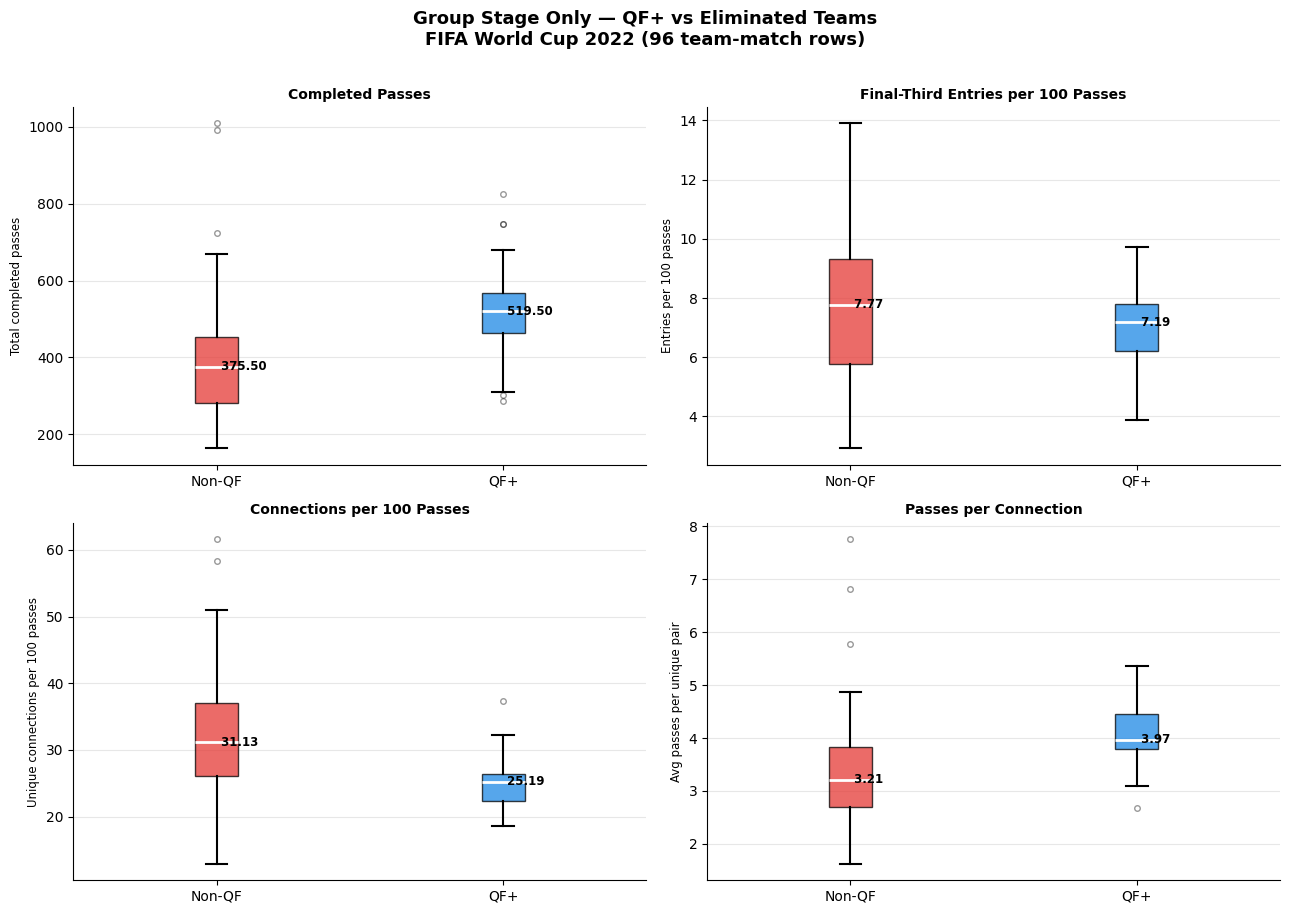

Saved: outputs/figures/05_group_stage_boxplots.png


In [8]:
QF_COLOR  = '#1E88E5'
ELM_COLOR = '#E53935'

def boxplot(ax, col, title, ylabel=None):
    """Single styled boxplot comparing non-QF vs QF+ for a given column."""
    bp = ax.boxplot(
        [non_gs[col].dropna(), qf_gs[col].dropna()],
        labels=['Non-QF', 'QF+'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markersize=4, alpha=0.4),
    )
    for patch, color in zip(bp['boxes'], [ELM_COLOR, QF_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    # Annotate medians
    for i, vals in enumerate([non_gs[col], qf_gs[col]]):
        med = vals.dropna().median()
        ax.text(i + 1, med, f' {med:.2f}', va='center', fontsize=8.5, fontweight='bold')
    ax.set_title(title, fontsize=10, fontweight='bold')
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=8.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)


# ── Four boxplots in a 2×2 grid ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    'Group Stage Only — QF+ vs Eliminated Teams\nFIFA World Cup 2022 (96 team-match rows)',
    fontsize=13, fontweight='bold', y=1.01,
)

boxplot(axes[0, 0], 'completed_passes',
        'Completed Passes', 'Total completed passes')

boxplot(axes[0, 1], 'final_third_entries_per_100_passes',
        'Final-Third Entries per 100 Passes', 'Entries per 100 passes')

boxplot(axes[1, 0], 'connections_per_100_passes',
        'Connections per 100 Passes', 'Unique connections per 100 passes')

boxplot(axes[1, 1], 'passes_per_connection',
        'Passes per Connection', 'Avg passes per unique pair')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_group_stage_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/05_group_stage_boxplots.png')

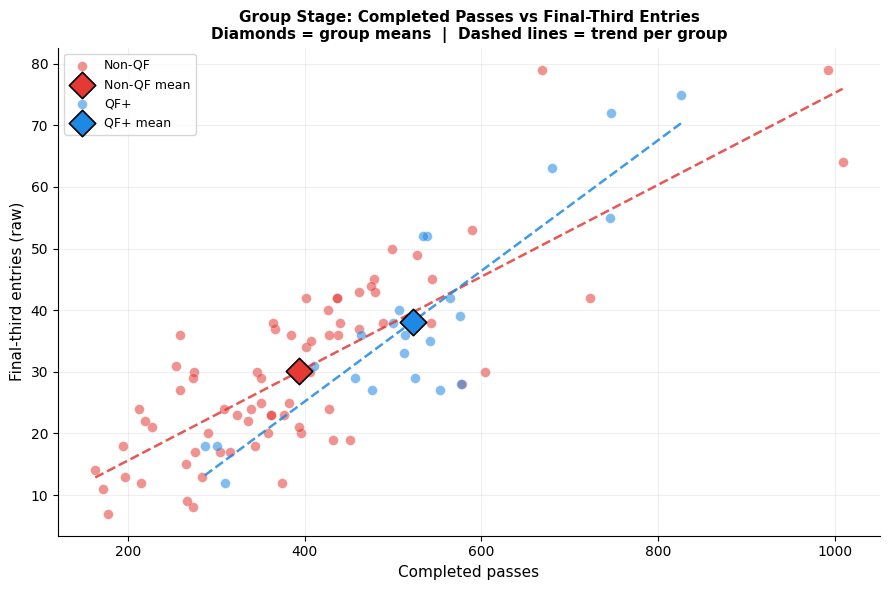

Saved: outputs/figures/05_group_stage_scatter.png


In [9]:
# ── Scatter: passes vs final-third entries (group stage only) ─────────────
fig, ax = plt.subplots(figsize=(9, 6))

for val, label, color in [(0, 'Non-QF', ELM_COLOR), (1, 'QF+', QF_COLOR)]:
    sub = gs[gs['reached_qf'] == val]
    ax.scatter(
        sub['completed_passes'], sub['final_third_entries'],
        c=color, alpha=0.55, s=50, label=label,
        edgecolors='white', linewidths=0.3,
    )
    # Trend line
    sub_clean = sub.dropna(subset=['completed_passes', 'final_third_entries'])
    z = np.polyfit(sub_clean['completed_passes'], sub_clean['final_third_entries'], 1)
    x_line = np.linspace(sub_clean['completed_passes'].min(),
                         sub_clean['completed_passes'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line),
            color=color, linewidth=1.8, linestyle='--', alpha=0.85)

    # Group mean as a large marker
    ax.scatter(
        sub['completed_passes'].mean(), sub['final_third_entries'].mean(),
        c=color, s=180, marker='D', edgecolors='black', linewidths=1.2,
        zorder=5, label=f'{label} mean',
    )

ax.set_xlabel('Completed passes', fontsize=11)
ax.set_ylabel('Final-third entries (raw)', fontsize=11)
ax.set_title(
    'Group Stage: Completed Passes vs Final-Third Entries\n'
    'Diamonds = group means  |  Dashed lines = trend per group',
    fontsize=11, fontweight='bold',
)
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_group_stage_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/05_group_stage_scatter.png')

## 5. Interpretation

### Did QF+ teams still complete more passes during the group stage?

Yes. The volume gap is already present in the group stage. QF+ teams averaged more completed passes per match than non-QF teams even before knockout rounds. The separation is visible in both the mean and median, and the scatter plot shows the QF+ mean diamond sitting noticeably to the right.

This suggests possession dominance is not a knockout-stage artifact — it was characteristic of these teams from matchday 1.

### Did QF+ teams still have more raw final-third entries?

Yes. QF+ teams generated more total final-third entries during the group stage. The scatter plot shows both a rightward (more passes) and upward (more entries) shift for QF+ teams relative to non-QF teams.

### Did QF+ teams have lower or higher final-third entries per 100 passes?

Lower — consistent with the full-dataset finding. When controlling for passing volume, non-QF teams converted a slightly higher share of their passes into final-third entries. This pattern holds in the group stage, not just overall.

This is an important nuance: QF+ teams' raw entry advantage was largely a volume effect. Their individual passes were not more likely to reach the final third.

### Did QF+ teams show more repeated passing relationships (higher passes per connection)?

Yes. The passes per connection gap is present in the group stage. QF+ teams used each passing connection more frequently, pointing to a more structured, repetitive passing style rather than a more varied one. Fewer unique connections per 100 passes, but each connection used more often — a tighter, more habitual network.

### Does the group-stage analysis support or weaken the earlier overall finding?

It **supports** it. The patterns identified across all stages — more passes, denser networks, higher passes per connection, slightly lower rate-based final-third penetration — are already visible in group-stage matches alone. They were not created by the selective survival of stronger teams in later rounds.

---

**Caution:** These patterns come from a single tournament (n = 32 teams, 3 matches each). Multiple rows per team means the rows are not independent — the same team's playing style appears in all three of its group matches. Treat these as descriptive patterns, not statistically confirmed predictors.

> **Working conclusion:** QF+ teams' passing-network profile — higher volume, denser connectivity, more repeated use of the same connections — was already present in the group stage. This suggests these metrics capture something real about how these teams play, not just how far they happened to go. The next step would be to look at per-team averages (one row per team, not one per match) to remove the repeated-rows issue and compare team-level profiles directly.

The group-stage-only results strengthen the overall finding that quarterfinal teams had a distinct passing-network profile from the beginning of the tournament. QF+ teams completed substantially more passes, had slightly denser networks, and generated more raw final-third entries even before knockout rounds began. However, their final-third entries per 100 passes were lower, suggesting that their attacking advantage came from sustained possession volume rather than greater directness per pass. Their lower connections per 100 passes and higher passes per connection also suggest more repeated and stable passing relationships. Overall, QF+ teams appeared to advance with controlled possession, consistent passing structures, and attacking accumulation rather than pure efficiency or reduced hub reliance.